In [1]:
import pandas as pd

df_sprint1 = pd.read_csv('/project_data/data_asset/op_analysis.csv')
df_sprint1.head()

,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,...,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,7,7,301.0,2020-03-30,2020-01-25,130843,66,1.000000,43.000000,0.106061,...,0.000000,0,0.5,0.000000,0.142857,0.000000,0.0,0.285714,0,0.0
1,8,11,352.0,2020-03-30,2020-01-06,157142,85,1.375000,44.000000,0.129412,...,0.125000,0,0.0,0.000000,0.125000,0.000000,0.0,0.375000,0,0.0
2,146,436,27615.0,2020-03-31,2020-01-02,116654,90,2.986301,189.143836,4.844444,...,0.034247,40,0.0,0.116438,0.136986,0.047945,0.0,0.979452,0,0.0
3,9,12,273.0,2020-03-01,2020-01-11,111791,51,1.333333,30.333333,0.235294,...,0.111111,0,0.0,0.000000,0.222222,0.111111,0.0,0.888889,0,0.0
4,70,185,7803.0,2020-03-31,2020-01-02,157094,90,2.642857,111.471429,2.055556,...,0.000000,4,0.0,0.000000,0.000000,0.014286,0.0,0.200000,0,0.0


In [2]:
df_sprint1['PR28'].describe()

count    13239.000000
mean         0.204652
std          0.280436
min          0.000000
25%          0.000000
50%          0.076923
75%          0.333333
max          1.000000
Name: PR28, dtype: float64

In [72]:

df_sprint1 = pd.read_csv('/project_data/data_asset/op_analysis_07012019_09302019.csv')
df_sprint1.head()


,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,3,5,120.0,2019-09-30,2019-08-25,158757,37,1.666667,40.000000,0.135135,3.243243,0.040816,0.000000,0,0.0,0.0,0.000000,0.000000,0.924242,0,0,0.0,0.000000,0,0.0,0.0,0.000000,0.0,0.000000,0.333333,0,0.000000
1,177,439,32077.0,2019-09-30,2019-07-01,2755,92,2.480226,181.225989,4.771739,348.663043,0.295775,0.011299,22,0.0,0.0,0.039007,0.241458,0.670420,0,0,0.0,0.079096,35,0.0,0.0,0.118644,0.0,0.016949,0.163842,0,0.022599
2,67,177,8075.0,2019-09-30,2019-07-01,157094,92,2.641791,120.522388,1.923913,87.771739,0.051329,0.000000,0,0.0,0.0,0.026144,0.045198,0.822467,0,0,0.0,0.000000,6,0.0,0.0,0.000000,0.0,0.000000,0.208955,0,0.000000
3,6,9,290.0,2019-09-28,2019-08-01,163295,59,1.500000,48.333333,0.152542,4.915254,0.083333,0.000000,0,0.0,0.0,0.000000,0.333333,0.923729,0,0,0.0,0.166667,0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0,0.000000
4,36,82,4219.0,2019-09-30,2019-07-01,112047,92,2.277778,117.194444,0.891304,45.858696,0.039152,0.000000,1,0.0,0.0,0.011429,0.292683,0.864238,0,0,0.0,0.000000,0,0.0,0.0,0.083333,0.0,0.000000,0.111111,0,0.000000


In [73]:
# import some libraries into the notebook
# all these libraries are pre-installed in Cloud Pak for Data

import pandas as pd
pd.set_option('display.max_columns', 500)
import numpy as np
import sys

from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import seaborn as sns
import matplotlib.pyplot as plt
#from matplotlib.pyplot import figure
%matplotlib inline

In [74]:
df_sprint1.describe()

,Member Count,Count Script,Sum Dispensed Quantity,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
count,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.0,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.0,13286.000000
mean,9.063902,17.967184,902.832903,117836.660093,53.396131,1.627068,69.752474,0.439538,17.222046,0.151559,0.045831,0.358422,0.000074,0.000669,0.011502,0.396728,0.797623,0.0,0.000828,0.000649,0.021600,1.691404,0.036403,0.002698,0.050021,0.000583,0.000010,0.218583,0.0,0.003087
std,16.364043,46.479322,3289.042543,41725.954254,33.687678,0.919531,84.830565,0.599271,42.316096,0.204067,0.171720,2.047078,0.000642,0.017767,0.058815,0.383026,0.191924,0.0,0.028763,0.019284,0.091195,13.005794,0.167000,0.035612,0.143523,0.012590,0.000791,0.287577,0.0,0.028753
min,1.000000,1.000000,0.360000,13.000000,1.000000,1.000000,0.360000,0.021739,0.035088,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,2.000000,2.000000,46.000000,107657.250000,20.000000,1.000000,16.500000,0.098120,2.309859,0.019231,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.735571,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
50%,4.000000,6.000000,156.000000,121878.000000,65.000000,1.250000,40.000000,0.195122,6.143718,0.075188,0.000000,0.000000,0.000000,0.000000,0.000000,0.300000,0.857143,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.111111,0.0,0.000000
75%,10.000000,16.000000,600.000000,144647.250000,84.000000,2.000000,90.000000,0.738043,16.721995,0.197322,0.000000,0.000000,0.000000,0.000000,0.000000,0.750000,0.928093,0.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.0,0.000000
max,301.000000,1603.000000,143680.500000,176132.000000,92.000000,13.000000,1470.000000,17.423913,1561.744565,1.000000,1.000000,67.000000,0.034483,1.000000,2.000000,1.000000,0.999052,0.0,1.000000,1.000000,1.000000,783.000000,1.000000,1.000000,1.000000,1.000000,0.083333,1.000000,0.0,1.000000


In [75]:
df_sprint1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13286 entries, 0 to 13285
Data columns (total 32 columns):
Member Count              13286 non-null int64
Count Script              13286 non-null int64
Sum Dispensed Quantity    13286 non-null float64
Max Dispense Date         13286 non-null object
Min Dispense Date         13286 non-null object
PRSCRB_PROV_LOC_ID        13286 non-null int64
Total Days                13286 non-null int64
PR2                       13286 non-null float64
PR1                       13286 non-null float64
PR4                       13286 non-null float64
PR3                       13286 non-null float64
PR5                       13286 non-null float64
PR6                       13286 non-null float64
PR7                       13286 non-null int64
PR8                       13286 non-null float64
PR9                       13286 non-null float64
PR10                      13286 non-null float64
PR11                      13286 non-null float64
PR13                 

In [76]:
df_sprint1.shape

(13286, 32)

In [77]:
# make lists of indicies and features for preprocessing pipeline

to_drop = []
index = ['PRSCRB_PROV_LOC_ID', 'Max Dispense Date', 'Min Dispense Date', 'PR1', 'PR11', 'PR13']
features = [c for c in df_sprint1.columns if c not in index or to_drop]
num_features = df_sprint1[features].select_dtypes('number').columns.tolist()

In [78]:
# redefine columns

features = [c for c in df_sprint1.columns if c not in to_drop+index]
num_features = df_sprint1[features].select_dtypes('number').columns.tolist()

In [79]:
num_features

['Member Count',
 'Count Script',
 'Sum Dispensed Quantity',
 'Total Days',
 'PR2',
 'PR4',
 'PR3',
 'PR5',
 'PR6',
 'PR7',
 'PR8',
 'PR9',
 'PR10',
 'PR15',
 'PR18',
 'PR19',
 'PR21',
 'PR22',
 'PR23',
 'PR24',
 'PR25',
 'PR26',
 'PR27',
 'PR28',
 'PR29',
 'PR30']

In [80]:
# define a preprocessor
# handle scaling and imputation

def preprocessor_sprint1(list_of_numerical_features):
    '''
    num_features is a python list of numerical features
    '''
    scaler = StandardScaler() # use robust or standard
    
    numerical_pipeline = make_pipeline(SimpleImputer(strategy='mean'), scaler)
    
    preprocessor = make_column_transformer((numerical_pipeline, list_of_numerical_features), remainder='drop')
    
    return preprocessor

In [81]:
# call the preprocessor
# see that the preprocessor is working
preprocessor_sprint1_regen = preprocessor_sprint1(num_features)

tmp = preprocessor_sprint1_regen.transformers[0][1].fit_transform(df_sprint1[num_features])
df_sprint1_processed = pd.DataFrame(data=tmp, columns=[c for c in num_features if df_sprint1[c].isna().all()==False], index=df_sprint1.index)
df_sprint1_processed.head()

,Member Count,Count Script,Sum Dispensed Quantity,Total Days,PR2,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,-0.370577,-0.278999,-0.238021,-0.486728,0.043066,-0.507974,-0.330355,-0.542701,-0.266907,-0.175096,-0.114718,-0.037663,-0.195566,0.0,-0.028786,-0.033668,-0.236864,-0.130055,-0.217989,-0.075769,-0.348536,-0.046347,-0.012668,0.399040,0.0,-0.107365
1,10.262893,9.058838,9.478546,1.145978,0.927854,7.229392,7.832799,0.706732,-0.201103,10.572332,-0.114718,-0.037663,0.467677,0.0,-0.028786,-0.033668,0.630500,2.561155,-0.217989,-0.075769,0.478149,-0.046347,21.424418,-0.190359,0.0,0.678632
2,3.540585,3.421711,2.180707,1.145978,1.103564,2.477062,1.667270,-0.491183,-0.266907,-0.175096,-0.114718,-0.037663,0.248961,0.0,-0.028786,-0.033668,-0.236864,0.331295,-0.217989,-0.075769,-0.348536,-0.046347,-0.012668,-0.033479,0.0,-0.107365
3,-0.187241,-0.192936,-0.186333,0.166354,-0.138193,-0.478925,-0.290841,-0.334345,-0.266907,-0.175096,-0.114718,-0.037663,-0.195566,0.0,-0.028786,-0.033668,1.590796,-0.130055,-0.217989,-0.075769,-0.348536,-0.046347,-0.012668,-0.760112,0.0,-0.107365
4,1.646116,1.377714,1.008285,1.145978,0.707681,0.753889,0.676757,-0.550858,-0.266907,0.313423,-0.114718,-0.037663,-0.001244,0.0,-0.028786,-0.033668,-0.236864,-0.130055,-0.217989,-0.075769,0.232112,-0.046347,-0.012668,-0.373728,0.0,-0.107365


In [82]:
pca = PCA()
X_pca = pca.fit(df_sprint1_processed)

Text(0, 0.5, 'cumulative explained variance')

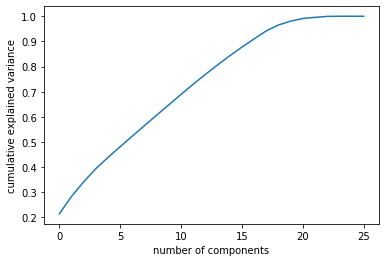

In [83]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')

In [84]:
pca = PCA(n_components = 0.60)
X_pca = pca.fit_transform(df_sprint1_processed)
print(pca.n_components_)

9


In [85]:
n_pcs= pca.n_components_ # get number of component
# get the index of the most important feature on EACH component
most_important = [np.abs(pca.components_[i]).argmax() for i in range(n_pcs)]
initial_feature_names = df_sprint1_processed.columns
# get the most important feature names
most_important_names = [initial_feature_names[most_important[i]] for i in range(n_pcs)]

In [86]:
print(most_important_names)

['Sum Dispensed Quantity', 'Total Days', 'PR25', 'PR28', 'PR23', 'PR26', 'PR18', 'PR27', 'PR19']


In [87]:
var = pca.explained_variance_ratio_
print(var)

[0.21419 0.0693  0.05824 0.05213 0.04481 0.04274 0.04218 0.0417  0.04163]


Text(0, 0.5, 'Explained Variance Ratio')

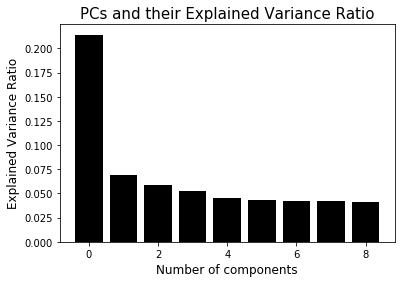

In [88]:
#Plot explained variance ratio for each PC
plt.bar([i for i, _ in enumerate(var)],var,color='black')
plt.title('PCs and their Explained Variance Ratio', fontsize=15)
plt.xlabel('Number of components',fontsize=12)
plt.ylabel('Explained Variance Ratio',fontsize=12)

In [89]:
#Cumulative Variance explained by each PC
cum_var = np.cumsum(np.round(pca.explained_variance_ratio_, decimals=4)*100)
print(cum_var)

[21.42 28.35 34.17 39.38 43.86 48.13 52.35 56.52 60.68]


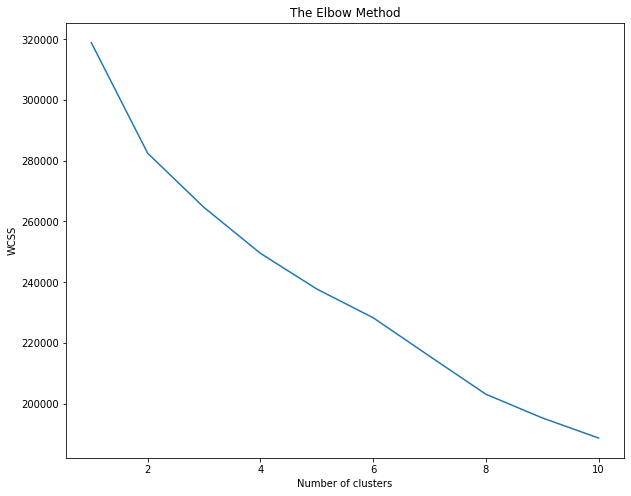

In [90]:
# find the appropriate cluster number
plt.figure(figsize=(10, 8))
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(df_sprint1_processed)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

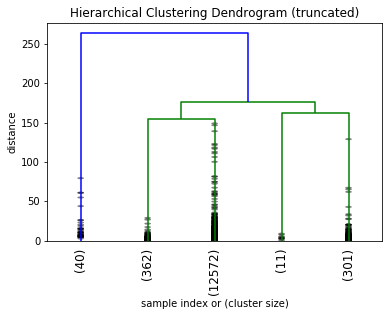

In [91]:
# Hierarchical clustering for the same dataset
# creating a dataset for hierarchical clustering
dataset2_standardized = df_sprint1_processed
# needed imports
from scipy.cluster.hierarchy import dendrogram, linkage

# some setting for this notebook to actually show the graphs inline
# you probably won't need this
%matplotlib inline
np.set_printoptions(precision=5, suppress=True)  # suppress scientific float notation
#creating the linkage matrix
H_cluster = linkage(dataset2_standardized,'ward')
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.xlabel('sample index or (cluster size)')
plt.ylabel('distance')
dendrogram(
    H_cluster,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=5,  # show only the last p merged clusters
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,  # to get a distribution impression in truncated branches
)
plt.show()

Text(0, 0.5, 'Cumulative Explained Variance Ratio')

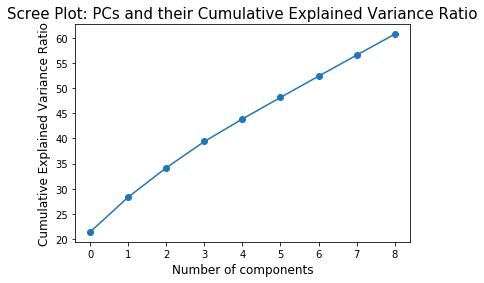

In [92]:
# Scree Plot
plt.plot(cum_var, marker='o')
plt.title('Scree Plot: PCs and their Cumulative Explained Variance Ratio',fontsize=15)
plt.xlabel('Number of components',fontsize=12)
plt.ylabel('Cumulative Explained Variance Ratio',fontsize=12)

In [93]:
#Fitting data into K-Means model with 3 clusters
km_4=KMeans(n_clusters=4,random_state=12345)
km_4.fit(df_sprint1_processed)
print(km_4.cluster_centers_)

[[-0.01098 -0.05536 -0.07234  0.54751  0.18787 -0.40657 -0.21126 -0.03734
  -0.0422  -0.05926 -0.00311 -0.00453  0.00988  0.      -0.00096 -0.01639
   0.01033 -0.03183 -0.08926 -0.00586 -0.00334  0.01102 -0.00062 -0.03892
   0.       0.02286]
 [10.11826 13.05431 14.64784  1.14598  2.12408 10.59774 12.20004  0.9416
  -0.15886 15.37611  1.33896  0.10889  1.23499  0.      -0.02879 -0.02422
   0.51173 10.11705 -0.2133  -0.04795  0.8135  -0.00382  2.08418  0.48782
   0.       1.03667]
 [-0.45074 -0.34683 -0.25781 -1.34938 -0.58537  0.5397   0.10956  0.06686
   0.11444 -0.16456 -0.07007  0.0093  -0.06578  0.      -0.00263  0.0346
  -0.04414 -0.11033  0.21123 -0.03293 -0.02304 -0.04635 -0.01267  0.06965
   0.      -0.10704]
 [ 3.05192  2.83253  2.3444   1.07077  1.20425  2.08453  2.00564  0.06085
  -0.15838  1.36923  0.51141 -0.00135  0.26649  0.       0.03795  0.01169
   0.13493  0.79634 -0.10598  0.35319  0.18553  0.16993 -0.01267  0.09222
   0.       0.37584]]


In [94]:
pd.Series(km_4.labels_).value_counts()

0    8747
2    3988
3     521
1      30
dtype: int64

In [95]:
from sklearn import metrics
metrics.silhouette_score(df_sprint1_processed, km_4.labels_)

0.2054648251494774

In [96]:
# calculate SC for K=2 through K=10
k_range = range(2, 10)
scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=12345)
    km.fit(df_sprint1_processed)
    scores.append(metrics.silhouette_score(df_sprint1_processed, km.labels_))

In [97]:
print(scores)

[0.7636537412057097, 0.1651232132115414, 0.2054648251494774, 0.2086869161399355, 0.20107721092864236, 0.20688408381551682, 0.22455158722274413, 0.22073634195331585]


In [98]:
from sklearn.metrics import davies_bouldin_score, silhouette_score, silhouette_samples
sse,db,slc = {}, {}, {}
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000,random_state=12345).fit(df_sprint1_processed)
    if k == 4: labels = kmeans.labels_
    clusters = kmeans.labels_
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
    db[k] = davies_bouldin_score(df_sprint1_processed,clusters)
    slc[k] = silhouette_score(df_sprint1_processed,clusters)

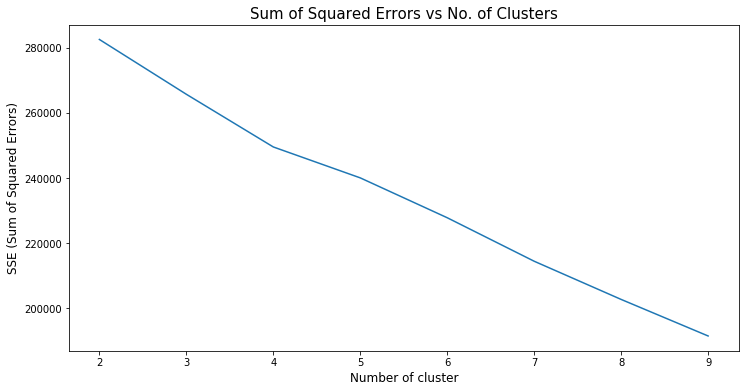

In [99]:
#Plotting SSE
plt.figure(figsize=(12,6))
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel("Number of cluster", fontsize=12)
plt.ylabel("SSE (Sum of Squared Errors)", fontsize=12)
plt.title("Sum of Squared Errors vs No. of Clusters", fontsize=15)
plt.show()

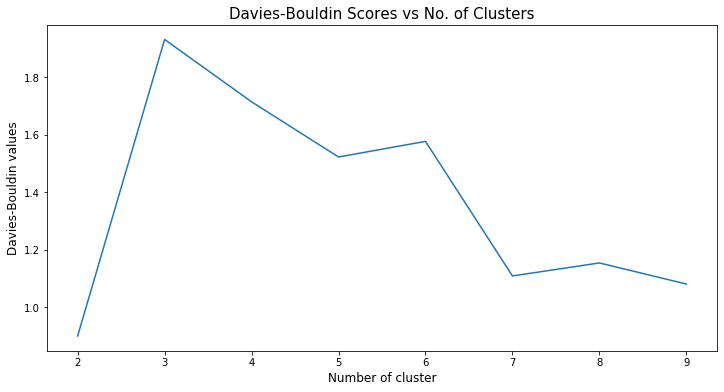

In [100]:
#Plotting Davies-Bouldin Scores
plt.figure(figsize=(12,6))
plt.plot(list(db.keys()), list(db.values()))
plt.xlabel("Number of cluster", fontsize=12)
plt.ylabel("Davies-Bouldin values", fontsize=12)
plt.title("Davies-Bouldin Scores vs No. of Clusters", fontsize=15)
plt.show()

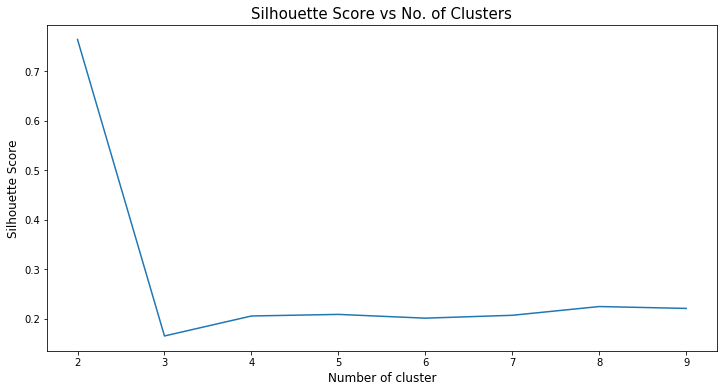

In [101]:
plt.figure(figsize=(12,6))
plt.plot(list(slc.keys()), list(slc.values()))
plt.xlabel("Number of cluster", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.title("Silhouette Score vs No. of Clusters", fontsize=15)
plt.show()

In [102]:
df_sprint1_processed2 = df_sprint1_processed

In [103]:
# start will the maximum number of components
# this helps to show us all the variance per component

pca = PCA(n_components=df_sprint1_processed2.shape[1]) #Initialize PCA with components = number variables in preprocessed dataframe
tmp_pca = pca.fit_transform(df_sprint1_processed2) #Call fit_transform method to apply PCA

# now we have the same result as we had in Sprint 1
# this can be read as, "First component explains 35.5% of variance in the data, second component explains 17.8% of variance in the data, ..."
# I will choose the first 3 to keep things simple and make clustering easily visual

pca.explained_variance_ratio_

array([0.21419, 0.0693 , 0.05824, 0.05213, 0.04481, 0.04274, 0.04218,
       0.0417 , 0.04163, 0.04125, 0.04114, 0.04034, 0.03912, 0.03768,
       0.03631, 0.03448, 0.03266, 0.03203, 0.02331, 0.01537, 0.01043,
       0.00454, 0.00369, 0.00072, 0.     , 0.     ])

In [104]:
# the variable `num_components_tokeep` can be changed to include more or less components for the clustering
# using the variable makes it easier for us to change if we want

num_components_tokeep = 5
df_for_clustering = pd.DataFrame(data=tmp_pca[:,:num_components_tokeep], columns=[(f'Comp {c}') for c in range(1,num_components_tokeep+1)], index=df_sprint1_processed2.index)
df_for_clustering.head()

,Comp 1,Comp 2,Comp 3,Comp 4,Comp 5
0,-0.851675,-0.121409,-0.337877,0.508589,-0.338645
1,22.487588,-2.802954,-0.648010,-0.570651,-0.467651
2,5.449323,0.259773,-1.462813,0.329888,-0.346092
3,-0.604123,0.412055,-0.079404,-0.032772,-0.157480
4,2.438086,0.780335,-1.022254,0.044532,-0.310025


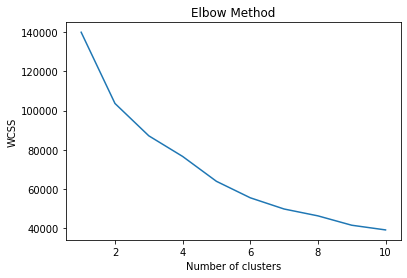

In [105]:
# make the Elbow Plot to see what is the ideal number of clusters

wcss = [] # within cluster sum of squares (sum of squared distance to cluster centroid)
for i in range(1, 11):
    #run k-means for clusters 1 - 11
    kmeans = KMeans(n_clusters=i, init='random', max_iter=300, n_init=10, random_state=12) 
    kmeans.fit(df_for_clustering)
    wcss.append(kmeans.inertia_) #inertia = wcss
plt.plot(range(1, 11), wcss)
#The elbow point indicates the number of clusters at which we've explained much of the variation in the
# reduced dataset without separating the data too much (with each observation being assigned to their own cluster 
# being maximum number of clusters and pretty pointless)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [106]:
# IMO, 4 is the ideal number of clusters, so that is how many i will use
number_of_clusters = 4

kmeans = KMeans(n_clusters=number_of_clusters, random_state=12) # make the clustering
kmeans.fit(df_for_clustering) # fit the clustering to the data
y_kmeans = kmeans.predict(df_for_clustering) # predict to get the labels

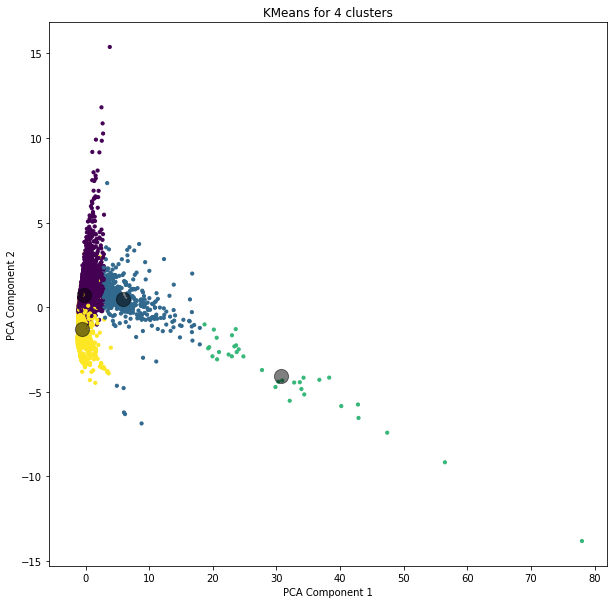

In [107]:
plt.figure(figsize=(10,10))
plt.scatter(df_for_clustering.iloc[:, 0], df_for_clustering.iloc[:, 1], c=y_kmeans, s=10, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)
plt.title('KMeans for 4 clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show();

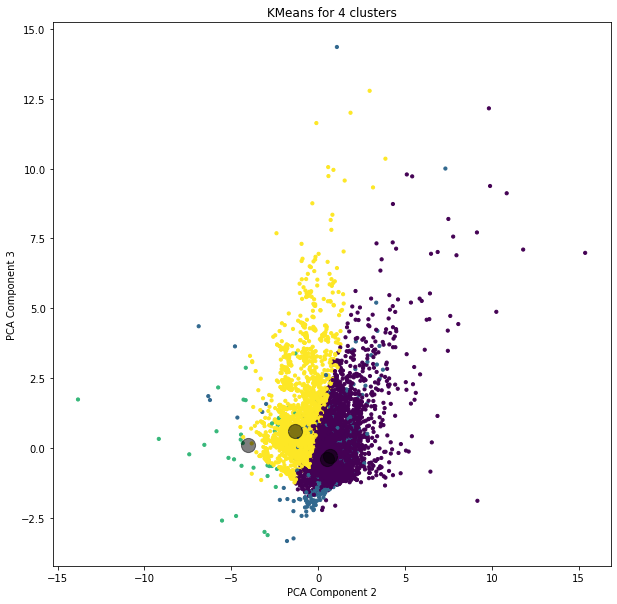

In [108]:
plt.figure(figsize=(10,10))
plt.scatter(df_for_clustering.iloc[:, 1], df_for_clustering.iloc[:, 2], c=y_kmeans, s=10, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)
plt.title('KMeans for 4 clusters')
plt.xlabel('PCA Component 2')
plt.ylabel('PCA Component 3')
plt.show();

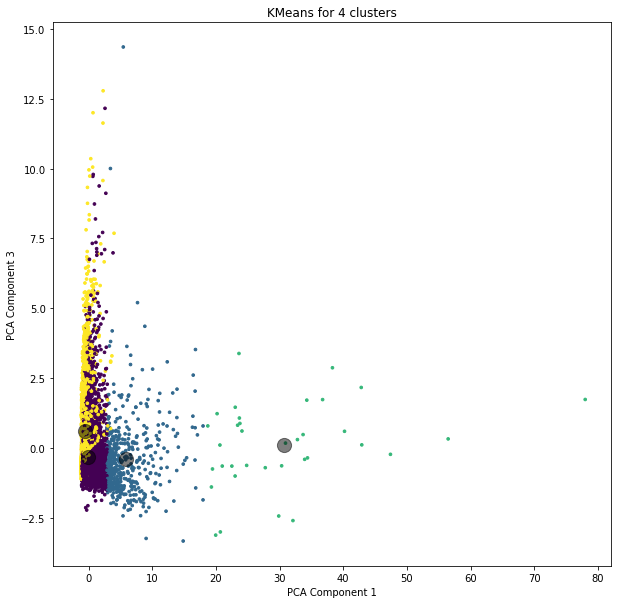

In [109]:
plt.figure(figsize=(10,10))
plt.scatter(df_for_clustering.iloc[:, 0], df_for_clustering.iloc[:, 2], c=y_kmeans, s=7, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 2], c='black', s=200, alpha=0.5)
plt.title('KMeans for 4 clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 3')

plt.show();

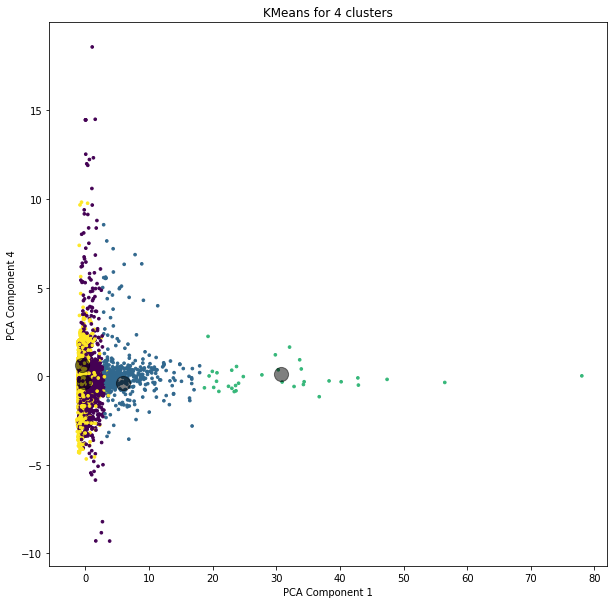

In [110]:
plt.figure(figsize=(10,10))
plt.scatter(df_for_clustering.iloc[:, 0], df_for_clustering.iloc[:, 3], c=y_kmeans, s=7, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 2], c='black', s=200, alpha=0.5)
plt.title('KMeans for 4 clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 4')

plt.show();

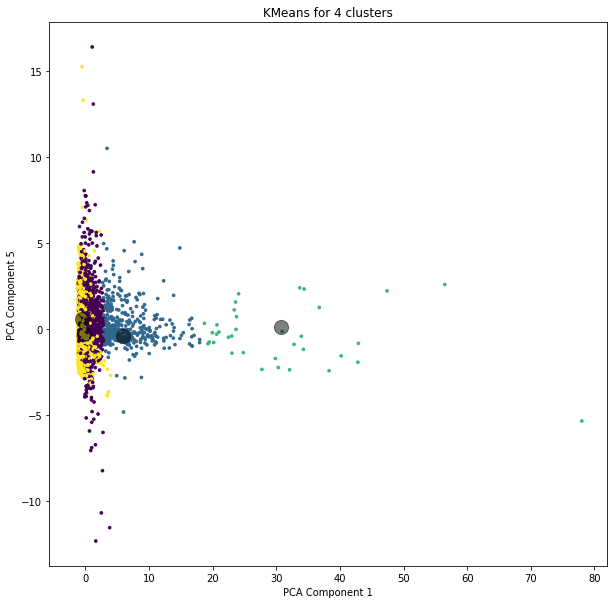

In [111]:
plt.figure(figsize=(10,10))
plt.scatter(df_for_clustering.iloc[:, 0], df_for_clustering.iloc[:, 4], c=y_kmeans, s=7, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 2], c='black', s=200, alpha=0.5)
plt.title('KMeans for 4 clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 5')

plt.show();

In [112]:
# calculate silhouette score of this clustering algorithm
sil_score = round(silhouette_score(df_for_clustering, y_kmeans), 3)
print(f'Silhouette score for 4 clusters is {sil_score}')

Silhouette score for 4 clusters is 0.295


In [65]:
# calculate silhouette score of this clustering algorithm
sil_score = round(silhouette_score(df_for_clustering, y_kmeans), 3)
print(f'Silhouette score for 8 clusters is {sil_score}')

Silhouette score for 8 clusters is 0.344


In [114]:
op_analysis_07012019_09302019 = df_sprint1['Cluster_label'] = pd.Series(y_kmeans, index=df_sprint1.index)
df_sprint1.head()

,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30,Cluster_label
0,3,5,120.0,2019-09-30,2019-08-25,158757,37,1.666667,40.000000,0.135135,3.243243,0.040816,0.000000,0,0.0,0.0,0.000000,0.000000,0.924242,0,0,0.0,0.000000,0,0.0,0.0,0.000000,0.0,0.000000,0.333333,0,0.000000,0
1,177,439,32077.0,2019-09-30,2019-07-01,2755,92,2.480226,181.225989,4.771739,348.663043,0.295775,0.011299,22,0.0,0.0,0.039007,0.241458,0.670420,0,0,0.0,0.079096,35,0.0,0.0,0.118644,0.0,0.016949,0.163842,0,0.022599,2
2,67,177,8075.0,2019-09-30,2019-07-01,157094,92,2.641791,120.522388,1.923913,87.771739,0.051329,0.000000,0,0.0,0.0,0.026144,0.045198,0.822467,0,0,0.0,0.000000,6,0.0,0.0,0.000000,0.0,0.000000,0.208955,0,0.000000,1
3,6,9,290.0,2019-09-28,2019-08-01,163295,59,1.500000,48.333333,0.152542,4.915254,0.083333,0.000000,0,0.0,0.0,0.000000,0.333333,0.923729,0,0,0.0,0.166667,0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0,0.000000,0
4,36,82,4219.0,2019-09-30,2019-07-01,112047,92,2.277778,117.194444,0.891304,45.858696,0.039152,0.000000,1,0.0,0.0,0.011429,0.292683,0.864238,0,0,0.0,0.000000,0,0.0,0.0,0.083333,0.0,0.000000,0.111111,0,0.000000,0


In [115]:
df_sprint1['Cluster_label'] = pd.Series(y_kmeans, index=df_sprint1.index)
df_sprint1.head()

,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30,Cluster_label
0,3,5,120.0,2019-09-30,2019-08-25,158757,37,1.666667,40.000000,0.135135,3.243243,0.040816,0.000000,0,0.0,0.0,0.000000,0.000000,0.924242,0,0,0.0,0.000000,0,0.0,0.0,0.000000,0.0,0.000000,0.333333,0,0.000000,0
1,177,439,32077.0,2019-09-30,2019-07-01,2755,92,2.480226,181.225989,4.771739,348.663043,0.295775,0.011299,22,0.0,0.0,0.039007,0.241458,0.670420,0,0,0.0,0.079096,35,0.0,0.0,0.118644,0.0,0.016949,0.163842,0,0.022599,2
2,67,177,8075.0,2019-09-30,2019-07-01,157094,92,2.641791,120.522388,1.923913,87.771739,0.051329,0.000000,0,0.0,0.0,0.026144,0.045198,0.822467,0,0,0.0,0.000000,6,0.0,0.0,0.000000,0.0,0.000000,0.208955,0,0.000000,1
3,6,9,290.0,2019-09-28,2019-08-01,163295,59,1.500000,48.333333,0.152542,4.915254,0.083333,0.000000,0,0.0,0.0,0.000000,0.333333,0.923729,0,0,0.0,0.166667,0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0,0.000000,0
4,36,82,4219.0,2019-09-30,2019-07-01,112047,92,2.277778,117.194444,0.891304,45.858696,0.039152,0.000000,1,0.0,0.0,0.011429,0.292683,0.864238,0,0,0.0,0.000000,0,0.0,0.0,0.083333,0.0,0.000000,0.111111,0,0.000000,0


In [85]:
#dataset without dropping pr1, 11, 13
pd.Series(y_kmeans).value_counts()

0    6250
3    4414
4    2165
1     378
2      32
dtype: int64

In [60]:
#4 clusters after dropping pr1, 11, 13
pd.Series(y_kmeans).value_counts()

3    7864
0    4766
2     568
1      41
dtype: int64

In [116]:
#8 clusters after dropping pr1, 11, 13
pd.Series(y_kmeans).value_counts()

0    8305
3    4451
1     495
2      35
dtype: int64

In [89]:
df_sprint2 = pd.read_csv('/project_data/data_asset/op_analysis_01012019_03312019.csv')
df_sprint2.head()
df_sprint3 = pd.read_csv('/project_data/data_asset/op_analysis_04012019_06302019.csv')
df_sprint3.head()
df_sprint5 = pd.read_csv('/project_data/data_asset/op_analysis_10012019_12312019.csv')
df_sprint5.head()
df_sprint4 = pd.read_csv('/project_data/data_asset/op_analysis_07012019_09302019.csv')
df_sprint4.head()

,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,3,5,120.0,2019-09-30,2019-08-25,158757,37,1.666667,40.000000,0.135135,3.243243,0.040816,0.000000,0,0.0,0.0,0.000000,0.000000,0.924242,0,0,0.0,0.000000,0,0.0,0.0,0.000000,0.0,0.000000,0.333333,0,0.000000
1,177,439,32077.0,2019-09-30,2019-07-01,2755,92,2.480226,181.225989,4.771739,348.663043,0.295775,0.011299,22,0.0,0.0,0.039007,0.241458,0.670420,0,0,0.0,0.079096,35,0.0,0.0,0.118644,0.0,0.016949,0.163842,0,0.022599
2,67,177,8075.0,2019-09-30,2019-07-01,157094,92,2.641791,120.522388,1.923913,87.771739,0.051329,0.000000,0,0.0,0.0,0.026144,0.045198,0.822467,0,0,0.0,0.000000,6,0.0,0.0,0.000000,0.0,0.000000,0.208955,0,0.000000
3,6,9,290.0,2019-09-28,2019-08-01,163295,59,1.500000,48.333333,0.152542,4.915254,0.083333,0.000000,0,0.0,0.0,0.000000,0.333333,0.923729,0,0,0.0,0.166667,0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0,0.000000
4,36,82,4219.0,2019-09-30,2019-07-01,112047,92,2.277778,117.194444,0.891304,45.858696,0.039152,0.000000,1,0.0,0.0,0.011429,0.292683,0.864238,0,0,0.0,0.000000,0,0.0,0.0,0.083333,0.0,0.000000,0.111111,0,0.000000


In [117]:
print(df_sprint1.loc[df_sprint1['PRSCRB_PROV_LOC_ID'].isin(['153504', '139433', '17522', '16638'])])

      Member Count  Count Script  Sum Dispensed Quantity Max Dispense Date  \
3260           142           737                 58832.0        2019-09-30   
4966           200           807                 71405.0        2019-09-30   
4974           301          1603                143680.5        2019-09-30   
6629           159           643                 53652.0        2019-09-30   

     Min Dispense Date  PRSCRB_PROV_LOC_ID  Total Days       PR2         PR1  \
3260        2019-07-01              139433          92  5.190141  414.309859   
4966        2019-07-01               17522          92  4.035000  357.025000   
4974        2019-07-01               16638          92  5.325581  477.343854   
6629        2019-07-01              153504          92  4.044025  337.433962   

            PR4          PR3       PR5       PR6  PR7       PR8       PR9  \
3260   8.010870   639.478261  0.297994  0.042254   54  0.000000  0.006993   
4966   8.771739   776.141304  0.452703  0.015000   54 

In [118]:
print(df_sprint1.loc[df_sprint1['Cluster_label'].isin(['2'])])

       Member Count  Count Script  Sum Dispensed Quantity Max Dispense Date  \
1               177           439               32077.000        2019-09-30   
6               210           783               66053.000        2019-09-30   
30              192           548               46036.000        2019-09-30   
75              182           569               28621.000        2019-09-30   
91              119           472               38064.000        2019-09-30   
121             183           396               28100.000        2019-09-30   
1636            148           639               58349.000        2019-09-30   
1660            178           471               39900.000        2019-09-30   
1689            149           394               27441.000        2019-09-26   
3249            139           642               56603.000        2019-09-30   
3260            142           737               58832.000        2019-09-30   
3279            130           396               3353

In [62]:
print(df_sprint1.loc[df_sprint1['PRSCRB_PROV_LOC_ID'].isin(['156800', '122949', '111813', '148485', 
                                                            '110160', '117265', '107410', '152853', '154518', '165594', '153504', '165027', '139433', '4457', '170094', '17522', '16638'])])

       Member Count  Count Script  Sum Dispensed Quantity Max Dispense Date  \
29               86           151                 10909.0        2020-03-31   
176              22            46                  2709.0        2020-03-19   
200              16            24                  2072.0        2020-03-28   
636              15            20                  1425.0        2020-02-28   
1591            162           514                 45477.0        2020-03-31   
3321            135           691                 54426.0        2020-03-31   
4971            208           842                 68946.0        2020-03-31   
4978            210           993                 82084.0        2020-03-31   
4984            296          1534                134140.0        2020-03-31   
6649            158           623                 43942.0        2020-03-31   
6655            215           643                 55388.0        2020-03-31   
6659            144           583                 50

In [120]:
print(df_sprint1.loc[df_sprint1['PRSCRB_PROV_LOC_ID'].isin(['156800', '122949', '111813', '148485', 
                                                            '110160', '117265', '107410', '152853', '154518', '165594', '153504', '165027', '139433', '4457', '170094', '17522', '16638'])])

       Member Count  Count Script  Sum Dispensed Quantity Max Dispense Date  \
6               210           783                 66053.0        2019-09-30   
91              119           472                 38064.0        2019-09-30   
121             183           396                 28100.0        2019-09-30   
247              42            72                  4868.0        2019-09-30   
252              78           138                 10912.0        2019-09-30   
1660            178           471                 39900.0        2019-09-30   
3260            142           737                 58832.0        2019-09-30   
4962            182           669                 55382.0        2019-09-30   
4966            200           807                 71405.0        2019-09-30   
4974            301          1603                143680.5        2019-09-30   
6629            159           643                 53652.0        2019-09-30   
6687            228           817                 73

In [102]:
df = pd.read_csv('/project_data/data_asset/op_analysis_with_nulls_with_labels.csv')
df.head()


,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30,Cluster_label
0,7,7,301.0,2020-03-30,2020-01-25,130843,66,1.000000,43.000000,0.106061,4.560606,0.048077,NaN,NaN,NaN,NaN,NaN,1.000000,0.860000,NaN,NaN,NaN,NaN,0.5,NaN,0.142857,NaN,NaN,0.285714,NaN,NaN,0
1,11,24,778.0,2020-03-31,2020-01-02,107152,90,2.181818,70.727273,0.266667,8.644444,0.231405,NaN,NaN,NaN,NaN,NaN,0.375000,0.862857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,9,16,391.0,2020-03-31,2020-01-06,128217,86,1.777778,43.444444,0.186047,4.546512,0.062500,NaN,NaN,NaN,NaN,0.044444,0.937500,0.928571,NaN,NaN,NaN,0.222222,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,21,22,399.0,2020-03-26,2020-01-01,106985,86,1.047619,19.000000,0.255814,4.639535,0.220930,NaN,NaN,NaN,NaN,0.022222,0.909091,0.676471,NaN,NaN,NaN,0.047619,NaN,NaN,0.047619,NaN,NaN,0.333333,NaN,NaN,1
4,11,20,711.0,2020-03-26,2020-01-07,171977,80,1.818182,64.636364,0.250000,8.887500,0.695652,NaN,NaN,NaN,NaN,0.090909,0.400000,0.636364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.272727,NaN,NaN,4


In [119]:
print(df.loc[df['PRSCRB_PROV_LOC_ID'].isin(['156800', '122949', '111813', '148485', 
                '110160', '117265', '107410', '152853', '154518', '165594', '153504', '165027', '139433', '4457', '170094', '17522', '16638'])])

NameError: name 'df' is not defined

In [104]:
print(df.loc[df['PRSCRB_PROV_LOC_ID'].isin(['153504', '139433', '17522', '16638'])])

      Member Count  Count Script  Sum Dispensed Quantity Max Dispense Date  \
3311           135           691                 54426.0        2020-03-31   
4956           296          1534                134140.0        2020-03-31   
4976           210           993                 82084.0        2020-03-31   
6608           144           583                 50783.0        2020-03-31   

     Min Dispense Date  PRSCRB_PROV_LOC_ID  Total Days       PR2         PR1  \
3311        2020-01-02              139433          90  5.118519  403.155556   
4956        2020-01-02               16638          90  5.182432  453.175676   
4976        2020-01-01               17522          91  4.728571  390.876190   
6608        2020-01-01              153504          91  4.048611  352.659722   

            PR4          PR3       PR5       PR6   PR7       PR8       PR9  \
3311   7.677778   604.733333  0.290662  0.037037  47.0       NaN  0.007752   
4956  17.044444  1490.444444  0.232002  0.027027  78

In [106]:
df['Cluster_label'].value_counts()

1    5223
0    5211
4    2041
3     693
2      71
Name: Cluster_label, dtype: int64

In [107]:
print(df.loc[df['PRSCRB_PROV_LOC_ID'].isin(['101075', '110876', '111813', '139433', '149990', '153826', '153997'])])


       Member Count  Count Script  Sum Dispensed Quantity Max Dispense Date  \
3311            135           691                 54426.0        2020-03-31   
10028            37           198                 14804.0        2020-03-31   
10187            21            33                  1820.0        2020-03-30   

      Min Dispense Date  PRSCRB_PROV_LOC_ID  Total Days       PR2         PR1  \
3311         2020-01-02              139433          90  5.118519  403.155556   
10028        2020-01-02              149990          90  5.351351  400.108108   
10187        2020-01-06              111813          85  1.571429   86.666667   

            PR4         PR3       PR5       PR6   PR7       PR8       PR9  \
3311   7.677778  604.733333  0.290662  0.037037  47.0       NaN  0.007752   
10028  2.200000  164.488889  0.430939       NaN  16.0  0.004246  0.025000   
10187  0.388235   21.411765  0.180328       NaN   1.0  0.003261       NaN   

           PR10      PR11      PR13  PR15  PR18  

In [ ]:
#op_analysis **01012020_03312020 wants 4 after dropping data
#op_analysis_07012019_09302019 wants 3 after dropping
#op_analysis_10012019_12312019 
